In [28]:
import pandas as pd 

import numpy as np 

import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

In [29]:
data = pd.read_csv('CARS.csv')

In [30]:
df = data.copy()

In [31]:
df.head(6)

,make,model,year,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption,co2_emissions,extra_field
0,Toyota,Camry,2023,Midsize,2.5,4,Automatic,Petrol,7.8,180,60
1,Toyota,Corolla,2024,Compact,1.8,4,CVT,Petrol,6.5,150,50
2,Toyota,RAV4,2023,SUV,2.5,4,Automatic,Hybrid,5.9,135,55
3,Toyota,Highlander,2023,SUV,3.5,6,Automatic,Petrol,10.2,235,70
4,Toyota,Land Cruiser,2024,SUV,4.0,6,Automatic,Petrol,14.0,320,100
5,Toyota,4Runner,2023,SUV,4.0,6,Automatic,Petrol,13.5,310,90


In [32]:
df = df[ df['co2_emissions'] < 431 ]
df = df[ df['co2_emissions'] > 110 ]

df = df.drop( ['make', 'model', 'year', 'vehicle_class', 'transmission', 'fuel_type', 'fuel_consumption', 'extra_field'], axis = 1 )

In [33]:
df.head()

,engine_size,cylinders,co2_emissions
0,2.5,4,180
1,1.8,4,150
2,2.5,4,135
3,3.5,6,235
4,4.0,6,320


In [34]:
x = df[[ 'engine_size', 'cylinders' ]]
y = df[[ 'co2_emissions' ]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 7)

print(f"\nX (Shape): {x_test.shape} | {x_train.shape}\nY (Shape): {y_test.shape} | {y_train.shape}\n")


X (Shape): (75, 2) | (172, 2)
Y (Shape): (75, 1) | (172, 1)



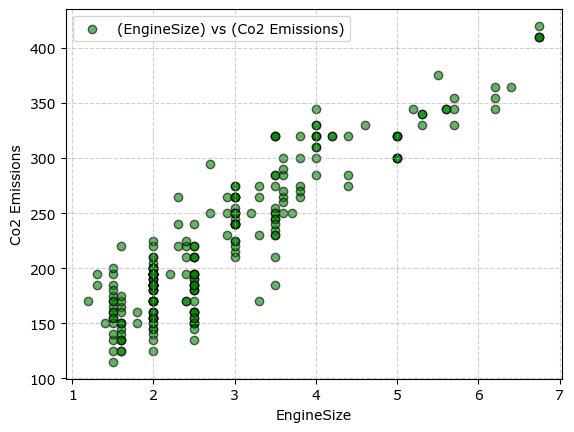

In [35]:
plt.scatter(df['engine_size'], df['co2_emissions'], color = 'g', edgecolor = 'k', alpha = 0.6, label = '(EngineSize) vs (Co2 Emissions)')

plt.xlabel('EngineSize')
plt.ylabel('Co2 Emissions')

plt.grid(True, alpha = 0.6, linestyle = '--')

plt.legend()

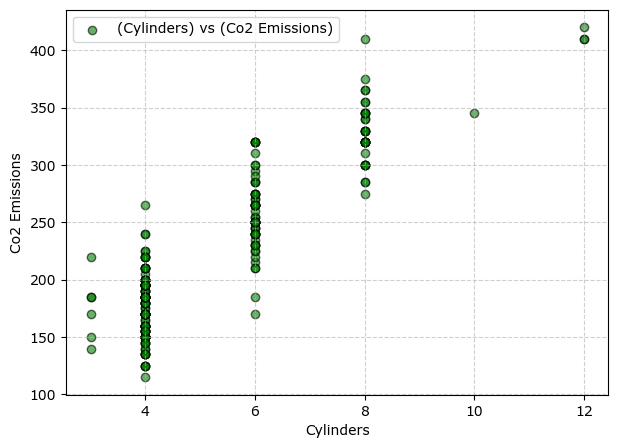

In [36]:
plt.figure( figsize = (7, 5) )

plt.scatter(df['cylinders'], df['co2_emissions'], color = 'g', edgecolor = 'k', alpha = 0.6, label = '(Cylinders) vs (Co2 Emissions)')

plt.xlabel('Cylinders')
plt.ylabel('Co2 Emissions')

plt.grid(True, alpha = 0.6, linestyle = '--')

plt.legend()

In [37]:
poly = PolynomialFeatures(degree = 2)

train_x_poly = poly.fit_transform(x_train)
test_x_poly = poly.transform(x_test)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_x_normalize_poly = scaler.fit_transform(train_x_poly)
test_x_normalize_poly = scaler.transform(test_x_poly)

In [39]:
regr = LinearRegression()

regr.fit(train_x_normalize_poly, y_train)

print(f"\nCOEFFICIENTS: {regr.coef_[0][0]} | {regr.coef_[0][1]} | {regr.coef_[0][2]} | {regr.coef_[0][3]} | {regr.coef_[0][4]} | {regr.coef_[0][5]}\n\nINTERCEPT: {regr.intercept_[0]}\n")


COEFFICIENTS: 0.0 | 79.17150732036852 | 9.820497837698015 | 109.04867720635418 | -276.49906588981855 | 145.88413939324582

INTERCEPT: 219.65116279069773



In [40]:
pred = regr.predict(test_x_normalize_poly)

In [41]:
print(f"\n1) R2-SCORE: {r2_score(y_test, pred):1.2f}\n\n2) MSE: {mean_squared_error(y_test, pred):1.2f}\n\n3) MAE: {mean_absolute_error(y_test, pred):1.2f}\n")


1) R2-SCORE: 0.87

2) MSE: 574.95

3) MAE: 17.72



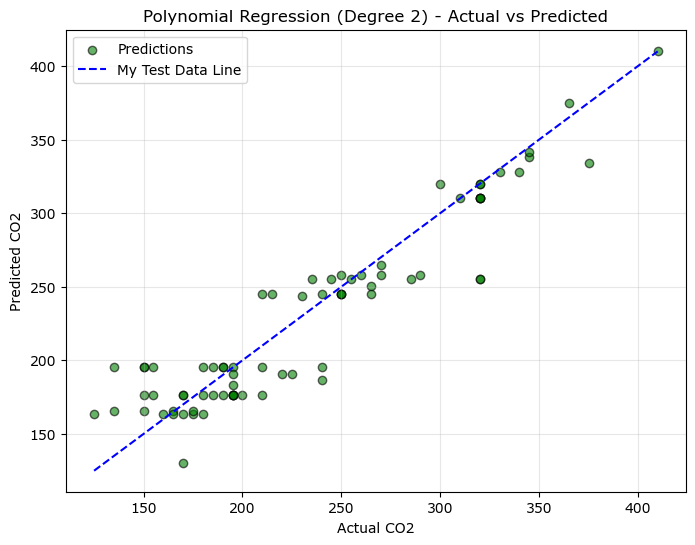

In [43]:
plt.figure( figsize=(8, 6) )

plt.scatter(y_test, pred, color='g', alpha=0.6, edgecolor='k', label='Predictions')

plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--b', label = 'My Test Data Line' )

plt.xlabel('Actual CO2')
plt.ylabel('Predicted CO2')

plt.title('Polynomial Regression (Degree 2) - Actual vs Predicted')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()